In [ ]:
# import os
# import pandas as pd
# import pyarrow as pa
# import pyarrow.parquet as pq
# from pathlib import Path
# import numpy as np

# base_dir = Path('E:/hneu/data')
# output_dir = Path('E:/hneu/processed_data')
# output_dir.mkdir(exist_ok=True)

# category_mapping = {
#     'fwdfinalconsumer': 'Consumer',
#     'fwdfinalenergyandultilities': 'EnergyAndUtilities',
#     'fwdfinalhealthcare': 'Healthcare',
#     'fwdfinalindustrials': 'Industrials',
#     'fwdfinalmaterials': 'Materials',
#     'fwdfinalrealestate': 'RealEstate',
#     'fwdfinaltelecompart1': 'Telecom',
#     'fwdfinaltelecompart2': 'Telecom'
# }

# def clean_numeric_value(x):
#     if pd.isna(x) or x == '' or x == 'NA' or x == 'NM':
#         return np.nan
#     if isinstance(x, str):
#         x = x.strip()
#         if x == 'NA' or x == 'NM':
#             return np.nan
#         if x.startswith('(') and x.endswith(')'):
#             x = '-' + x[1:-1]
#         x = x.replace(',', '').replace(' ', '')
#         try:
#             return float(x)
#         except:
#             return np.nan
#     return x

# for category_folder in base_dir.iterdir():
#     if not category_folder.is_dir() or 'fwdfinal' not in category_folder.name:
#         continue
    
#     category_name = category_mapping.get(category_folder.name, 'Unknown')
#     category_output = output_dir / category_name
#     category_output.mkdir(exist_ok=True)
    
#     for excel_file in category_folder.glob('*.xlsx'):
#         country_name = excel_file.stem
#         country_output = category_output / country_name
#         country_output.mkdir(exist_ok=True)
        
#         try:
#             df = pd.read_excel(excel_file, header=None)
            
#             if len(df) < 6:
#                 continue
                
#             col_names = df.iloc[2].values
#             field_codes = df.iloc[3].values
#             periods = df.iloc[4].values
            
#             columns = []
#             for i in range(len(col_names)):
#                 col_name = str(col_names[i]).strip() if not pd.isna(col_names[i]) else f'col_{i}'
#                 period = str(periods[i]).strip() if not pd.isna(periods[i]) else 'Unknown'
#                 if col_name == 'nan' or col_name == '':
#                     col_name = f'col_{i}'
#                 if period == 'nan' or period == '':
#                     period = 'Unknown'
#                 columns.append(f'{col_name}_{period}')
            
#             data_df = df.iloc[5:].copy()
#             data_df.columns = columns
            
#             for col in data_df.columns:
#                 data_df[col] = data_df[col].apply(clean_numeric_value)
            
#             data_df = data_df[~data_df.apply(lambda row: row.astype(str).isin(["NA", 'NA', "N/A", "na"]).any(), axis=1)]
#             data_df = data_df.dropna(how='all')
            
#             if not data_df.empty:
#                 json_path = country_output / f'{country_name}_{category_name}.json'
#                 parquet_path = country_output / f'{country_name}_{category_name}.parquet'
                
#                 data_df.to_json(json_path, orient='records', indent=2)
                
#                 table = pa.Table.from_pandas(data_df)
#                 pq.write_table(table, parquet_path)
                
#         except Exception as e:
#             print(f'Error processing {excel_file}: {str(e)}')

Error processing E:\hneu\data\fwdfinalconsumer\~$Argentina.xlsx: [Errno 13] Permission denied: 'E:\\hneu\\data\\fwdfinalconsumer\\~$Argentina.xlsx'


In [4]:
import duckdb

parquet_file = "E:\hneu\processed_data\EnergyAndUtilities\Argentina\Argentina_EnergyAndUtilities.parquet"

con = duckdb.connect()

try:
    result = con.execute(f"""
        DESCRIBE SELECT *
        FROM read_parquet('{parquet_file}')
    """).fetchdf()

    print(result.to_string())

except Exception as e:
    print(f"Error: {e}")

finally:
    con.close()


                                                    column_name column_type null   key default extra
0                                           Entity Name_Unknown      DOUBLE  YES  None    None  None
1                                             Entity ID_Unknown      DOUBLE  YES  None    None  None
2                                      Ownership Status_Unknown      DOUBLE  YES  None    None  None
3                               Industry Classification_Unknown      DOUBLE  YES  None    None  None
4                       Gross Profit\n($000)_Latest Fiscal Year      DOUBLE  YES  None    None  None
5                   Interest Expense\n($000)_Latest Fiscal Year      DOUBLE  YES  None    None  None
6    Net Property, Plant & Equipment\n($000)_Latest Fiscal Year      DOUBLE  YES  None    None  None
7                       Total Assets\n($000)_Latest Fiscal Year      DOUBLE  YES  None    None  None
8                         Total Debt\n($000)_Latest Fiscal Year      DOUBLE  YES  None    N

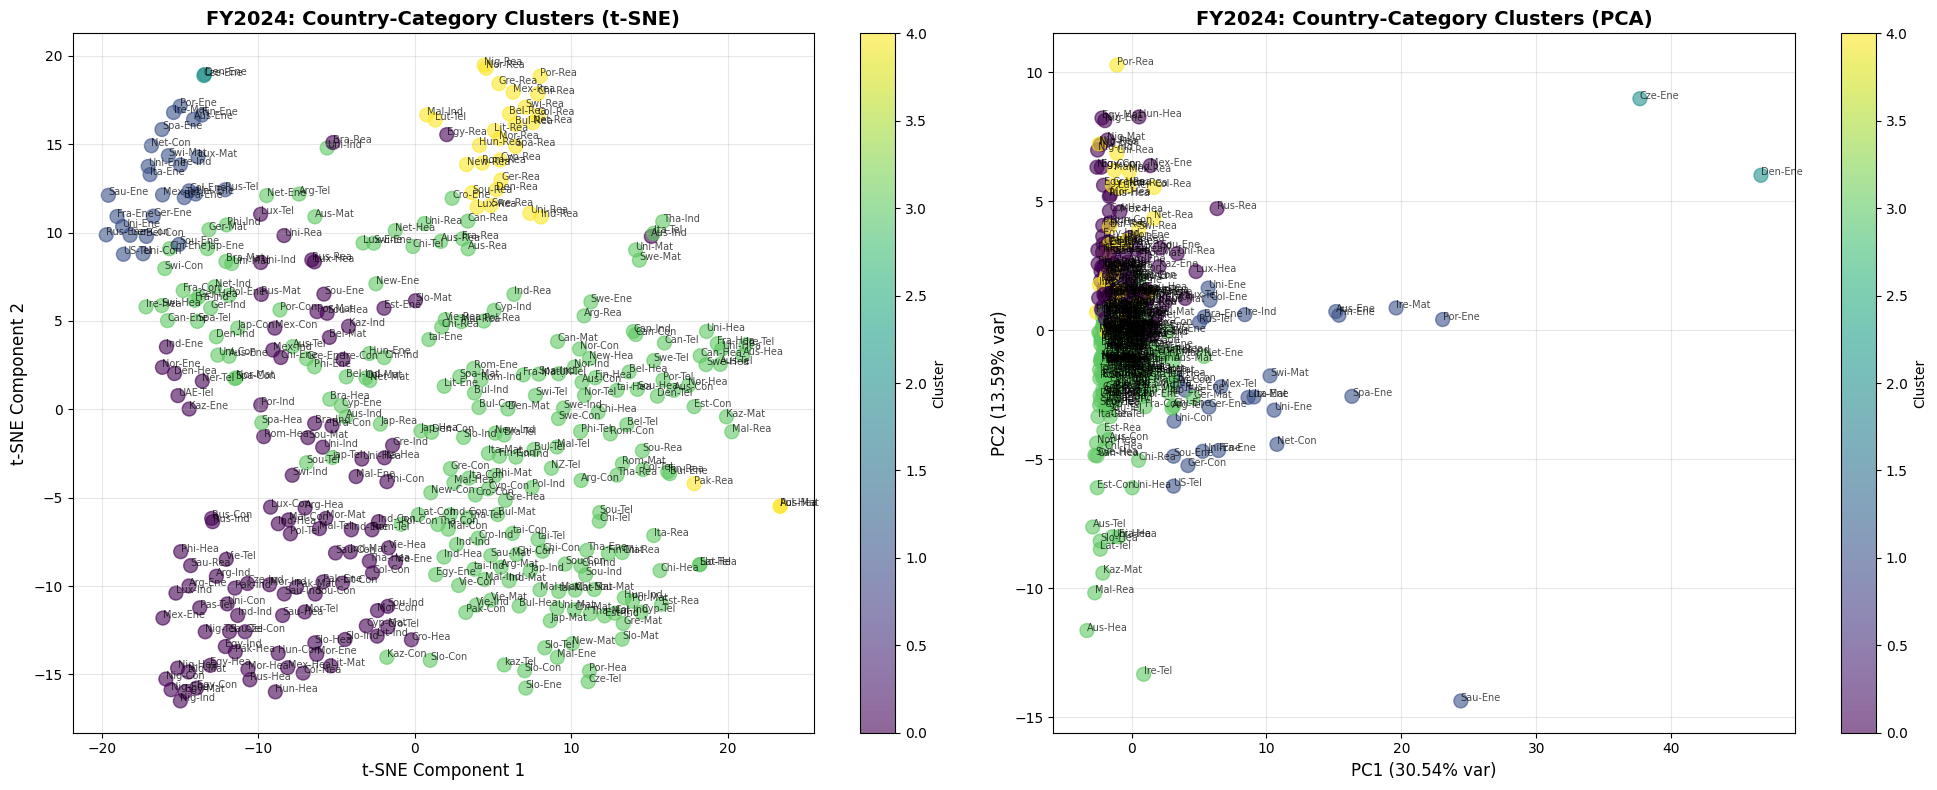

Total country-category pairs in FY2024: 367
Number of clusters: 5

PCA explained variance ratio (top 10 components):
[0.30539386 0.13589204 0.11285311 0.08647035 0.05591195 0.04306895
 0.03077676 0.02857541 0.02453275 0.02366315]

Cumulative variance explained: 84.71%

Cluster distribution:
Cluster
0    [(Brazil, Consumer), (Colombia, Consumer), (Cz...
1    [(Belgium, Consumer), (Germany, Consumer), (Ne...
2    [(Czechia, EnergyAndUtilities), (Denmark, Ener...
3    [(Argentina, Consumer), (Australia, Consumer),...
4    [(Poland, Healthcare), (Malta, Industrials), (...
dtype: object

Data saved to country_category_vectors.csv


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

base_dir = Path('E:/hneu/processed_data')

fiscal_years = ['FY2024', 'FY2023', 'FY2022', 'FY2021', 'FY2020', 'FY2019', 'FY2018', 'Latest Fiscal Year']

indicator_base_names = [
    'Gross Profit Margin\n(%)',
    'EBITDA Margin\n(%)',
    'Net Income Margin\n(%)',
    'Return on Assets\n(%)',
    'Return on Capital\n(%)',
    'Return on Equity\n(%)',
    'Total Revenues, 1 Year Growth\n(%)',
    'Gross Profit\n($000)',
    'Interest Expense\n($000)',
    'Net Property, Plant & Equipment\n($000)',
    'Total Assets\n($000)',
    'Total Debt\n($000)',
    'Total Equity\n($000)',
    'Capital Expenditure\n($000)'
]

all_data = []

for category_dir in base_dir.iterdir():
    if not category_dir.is_dir():
        continue
    
    category_name = category_dir.name
    
    for country_dir in category_dir.iterdir():
        if not country_dir.is_dir():
            continue
        
        country_name = country_dir.name
        
        for parquet_file in country_dir.glob('*.parquet'):
            df = pd.read_parquet(parquet_file)
            
            for fy in fiscal_years:
                fy_label = 'FY2025' if fy == 'Latest Fiscal Year' else fy
                
                indicator_cols = [f'{ind}_{fy}' for ind in indicator_base_names]
                available_cols = [col for col in indicator_cols if col in df.columns]
                
                if len(available_cols) < len(indicator_base_names):
                    continue
                
                df_fy = df[available_cols].copy()
                df_fy = df_fy.dropna()
                
                if len(df_fy) == 0:
                    continue
                
                aggregated_values = []
                
                for col in available_cols:
                    values = df_fy[col].values
                    
                    if len(values) > 0:
                        aggregated_values.extend([
                            np.mean(values),
                            np.std(values),
                            np.median(values),
                            np.percentile(values, 25),
                            np.percentile(values, 75)
                        ])
                    else:
                        aggregated_values.extend([np.nan] * 5)
                
                all_data.append({
                    'Category': category_name,
                    'Country': country_name,
                    'FiscalYear': fy_label,
                    'Vector': aggregated_values,
                    'NumCompanies': len(df_fy)
                })

df_aggregated = pd.DataFrame(all_data)

vector_df = pd.DataFrame(df_aggregated['Vector'].tolist())
df_final = pd.concat([df_aggregated[['Category', 'Country', 'FiscalYear', 'NumCompanies']], vector_df], axis=1)

df_final = df_final.dropna()

df_fy2024 = df_final[df_final['FiscalYear'] == 'FY2024'].copy()

if len(df_fy2024) > 0:
    X = df_fy2024.iloc[:, 4:].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_components = min(10, X_scaled.shape[1], X_scaled.shape[0])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    optimal_k = min(5, len(df_fy2024) - 1)
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_fy2024['Cluster'] = kmeans.fit_predict(X_pca)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_fy2024) - 1))
    X_tsne = tsne.fit_transform(X_pca)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    scatter = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                             c=df_fy2024['Cluster'], 
                             cmap='viridis', 
                             s=100, 
                             alpha=0.6)
    
    for idx, row in df_fy2024.iterrows():
        axes[0].annotate(f"{row['Country'][:3]}-{row['Category'][:3]}", 
                        (X_tsne[df_fy2024.index.get_loc(idx), 0], 
                         X_tsne[df_fy2024.index.get_loc(idx), 1]),
                        fontsize=7, alpha=0.7)
    
    axes[0].set_xlabel('t-SNE Component 1', fontsize=12)
    axes[0].set_ylabel('t-SNE Component 2', fontsize=12)
    axes[0].set_title('FY2024: Country-Category Clusters (t-SNE)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='Cluster')
    
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    
    scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                              c=df_fy2024['Cluster'], 
                              cmap='viridis', 
                              s=100, 
                              alpha=0.6)
    
    for idx, row in df_fy2024.iterrows():
        axes[1].annotate(f"{row['Country'][:3]}-{row['Category'][:3]}", 
                        (X_pca_2d[df_fy2024.index.get_loc(idx), 0], 
                         X_pca_2d[df_fy2024.index.get_loc(idx), 1]),
                        fontsize=7, alpha=0.7)
    
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=12)
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=12)
    axes[1].set_title('FY2024: Country-Category Clusters (PCA)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Cluster')
    
    plt.tight_layout()
    plt.savefig('fy2024_clustering.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Total country-category pairs in FY2024: {len(df_fy2024)}")
    print(f"Number of clusters: {optimal_k}")
    print(f"\nPCA explained variance ratio (top {n_components} components):")
    print(pca.explained_variance_ratio_)
    print(f"\nCumulative variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    print("\nCluster distribution:")
    print(df_fy2024.groupby('Cluster')[['Category', 'Country']].apply(lambda x: list(zip(x['Country'], x['Category']))))

df_final.to_csv('country_category_vectors.csv', index=False)
print("\nData saved to country_category_vectors.csv")

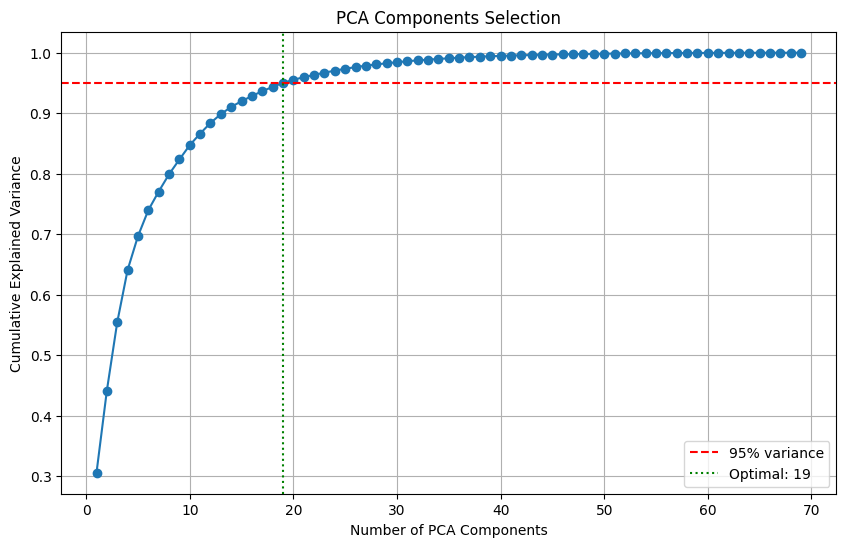

Optimal PCA components: 19


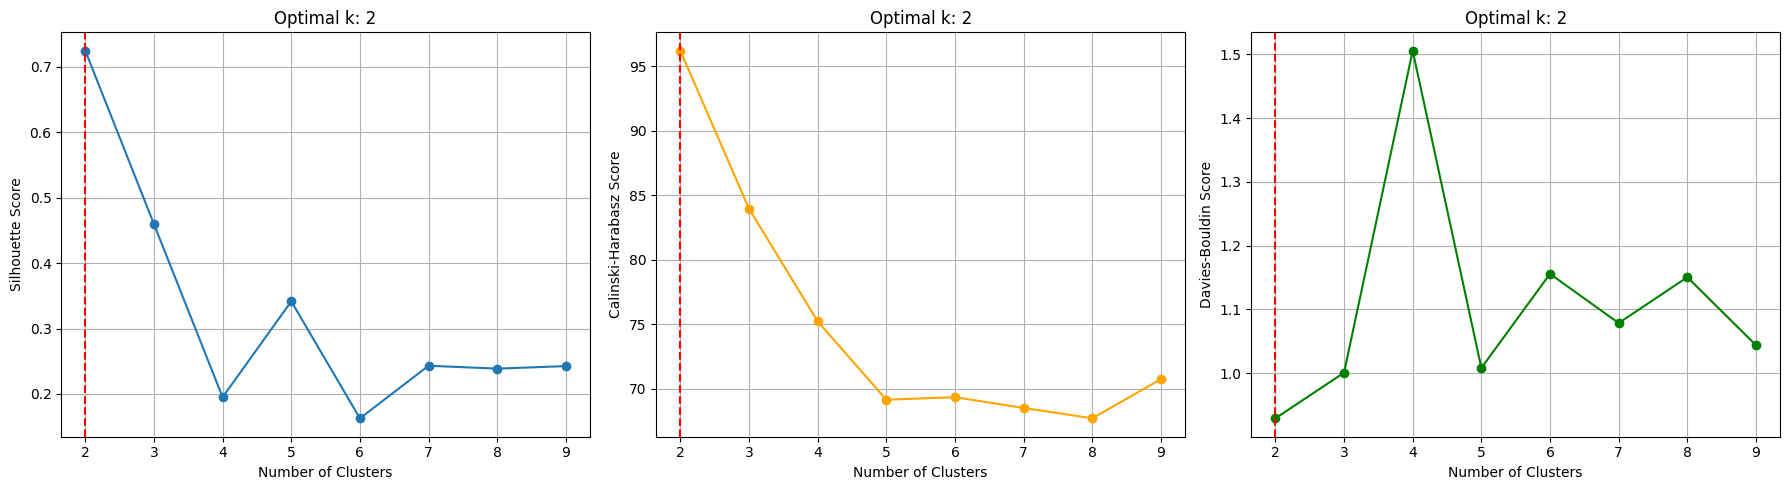

Final Clustering Results:
Number of clusters: 2
PCA components: 19
Silhouette Score: 0.7247
Calinski-Harabasz Score: 96.1957
Davies-Bouldin Score: 0.9291

Cluster sizes:
Cluster 0: 359 samples
Cluster 1: 8 samples


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_fy2024 = pd.read_csv('country_category_vectors.csv')
df_fy2024 = df_fy2024[df_fy2024['FiscalYear'] == 'FY2024']
df_fy2024 = df_fy2024.dropna()

X_original = df_fy2024.iloc[:, 4:].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

n_samples = X_scaled.shape[0]
n_features = X_scaled.shape[1]

explained_variances = []
for n in range(1, min(n_features, n_samples)):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)
    explained_variances.append(np.sum(pca.explained_variance_ratio_))

optimal_pca_idx = np.argmax(np.array(explained_variances) >= 0.95)
optimal_pca_components = optimal_pca_idx + 1 if optimal_pca_idx < len(explained_variances) else len(explained_variances)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variances) + 1), explained_variances, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=optimal_pca_components, color='g', linestyle=':', label=f'Optimal: {optimal_pca_components}')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Components Selection')
plt.legend()
plt.grid(True)
plt.savefig('pca_variance.png')
plt.show()

print(f"Optimal PCA components: {optimal_pca_components}")

pca_optimal = PCA(n_components=optimal_pca_components)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

silhouette_scores = []
ch_scores = []
db_scores = []
k_range = range(2, min(10, n_samples))

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_optimal)
    
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X_pca_optimal, labels))
        ch_scores.append(calinski_harabasz_score(X_pca_optimal, labels))
        db_scores.append(davies_bouldin_score(X_pca_optimal, labels))
    else:
        silhouette_scores.append(0)
        ch_scores.append(0)
        db_scores.append(np.inf)

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)] if silhouette_scores else 2
optimal_k_ch = k_range[np.argmax(ch_scores)] if ch_scores else 2
optimal_k_db = k_range[np.argmin(db_scores)] if db_scores else 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, silhouette_scores, marker='o')
axes[0].axvline(x=optimal_k_silhouette, color='r', linestyle='--')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title(f'Optimal k: {optimal_k_silhouette}')
axes[0].grid(True)

axes[1].plot(k_range, ch_scores, marker='o', color='orange')
axes[1].axvline(x=optimal_k_ch, color='r', linestyle='--')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Calinski-Harabasz Score')
axes[1].set_title(f'Optimal k: {optimal_k_ch}')
axes[1].grid(True)

axes[2].plot(k_range, db_scores, marker='o', color='green')
axes[2].axvline(x=optimal_k_db, color='r', linestyle='--')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title(f'Optimal k: {optimal_k_db}')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('cluster_metrics.png')
plt.show()

kmeans_final = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(X_pca_optimal)

silhouette_final = silhouette_score(X_pca_optimal, final_labels)
ch_final = calinski_harabasz_score(X_pca_optimal, final_labels)
db_final = davies_bouldin_score(X_pca_optimal, final_labels)

print(f"Final Clustering Results:")
print(f"Number of clusters: {optimal_k_silhouette}")
print(f"PCA components: {optimal_pca_components}")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"Calinski-Harabasz Score: {ch_final:.4f}")
print(f"Davies-Bouldin Score: {db_final:.4f}")
print(f"\nCluster sizes:")
unique, counts = np.unique(final_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

cluster_stats = pd.DataFrame({
    'Cluster': final_labels,
    'Country': df_fy2024['Country'].values,
    'Category': df_fy2024['Category'].values
})
cluster_stats.to_csv('cluster_assignments.csv', index=False)

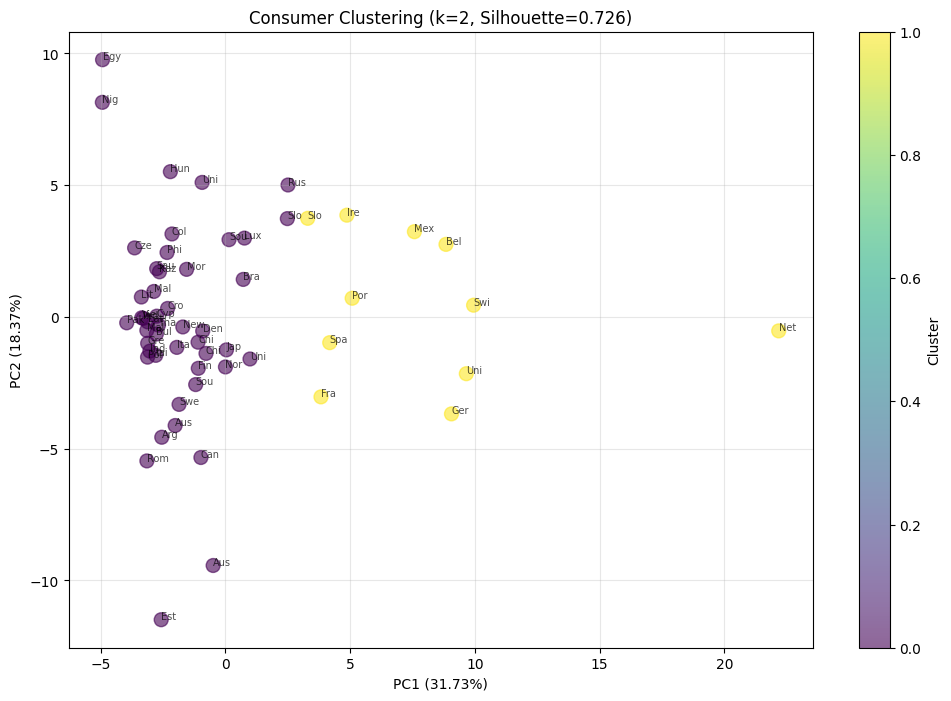


=== Consumer ===
Samples: 58
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.7258
Calinski-Harabasz Score: 120.1698
Davies-Bouldin Score: 0.4882
Cluster distribution:
  Cluster 0: 47 samples
  Cluster 1: 11 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Australia', 'Austria', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'Greece', 'Hungary', 'India', 'Indonesia', 'Italy', 'Japan', 'Kazakhstan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Morocco', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Philippines', 'Poland', 'Romania', 'Russia', 'Saudi Arabia', 'Slovakia', 'South Africa', 'South Korea', 'Sweden', 'taiwan', 'Thailand', 'United Arab Emirates', 'United Kingdom', 'Vietnam']
  Cluster 1: ['Belgium', 'France', 'Germany', 'Ireland', 'Mexico', 'Netherlands', 'Portugal', 'Slovenia', 'Spain', 'Switzerland', 'United States']


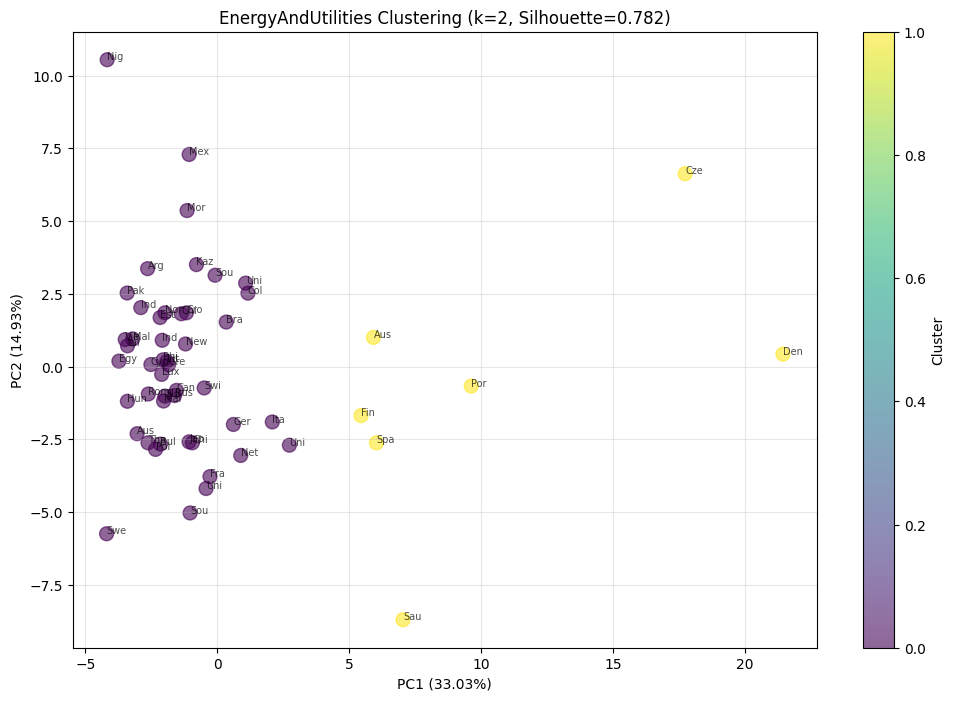


=== EnergyAndUtilities ===
Samples: 54
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.7817
Calinski-Harabasz Score: 124.9898
Davies-Bouldin Score: 0.5364
Cluster distribution:
  Cluster 0: 47 samples
  Cluster 1: 7 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Australia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Egypt', 'Estonia', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Indonesia', 'Italy', 'Japan', 'Kazakhstan', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Philippines', 'Poland', 'Romania', 'Russia', 'Slovenia', 'South Africa', 'South Korea', 'Sweden', 'Switzerland', 'taiwan', 'Thailand', 'United Arab Emirates', 'United Kingdom', 'United States', 'Vietnam']
  Cluster 1: ['Austria', 'Czechia', 'Denmark', 'Finland', 'Portugal', 'Saudi Arabia', 'Spain']


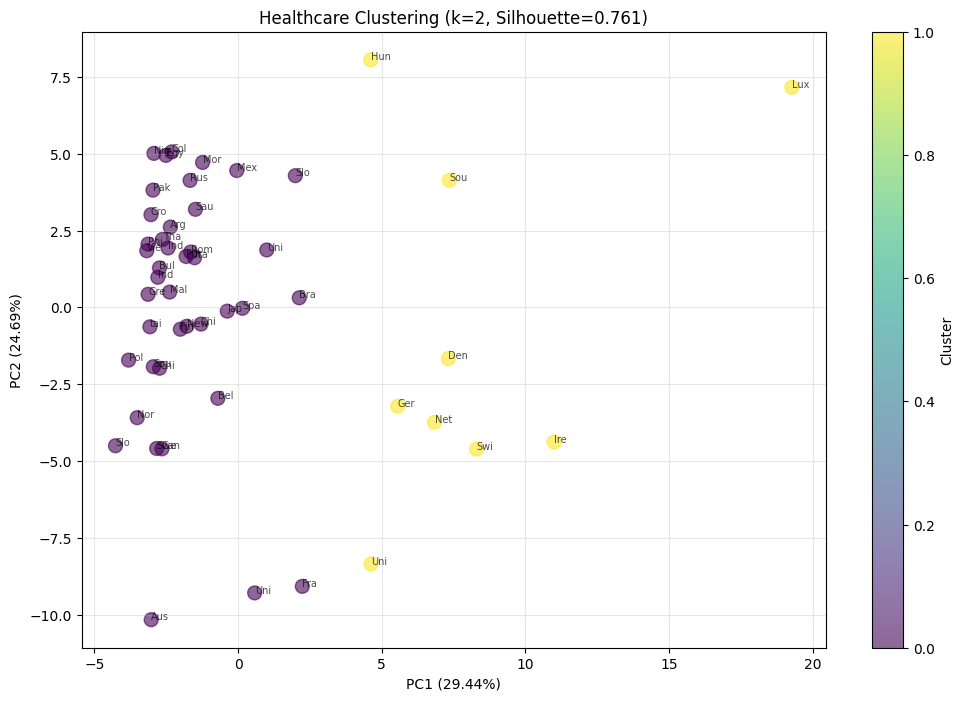


=== Healthcare ===
Samples: 50
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.7614
Calinski-Harabasz Score: 134.6975
Davies-Bouldin Score: 0.4213
Cluster distribution:
  Cluster 0: 41 samples
  Cluster 1: 9 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Australia', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Egypt', 'Finland', 'France', 'Greece', 'India', 'Indonesia', 'Italy', 'Japan', 'Malaysia', 'Mexico', 'Morocco', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Slovakia', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'taiwan', 'Thailand', 'United Arab Emirates', 'United Kingdom', 'Vietnam']
  Cluster 1: ['Denmark', 'Germany', 'Hungary', 'Ireland', 'Luxembourg', 'Netherlands', 'South Africa', 'Switzerland', 'United States']


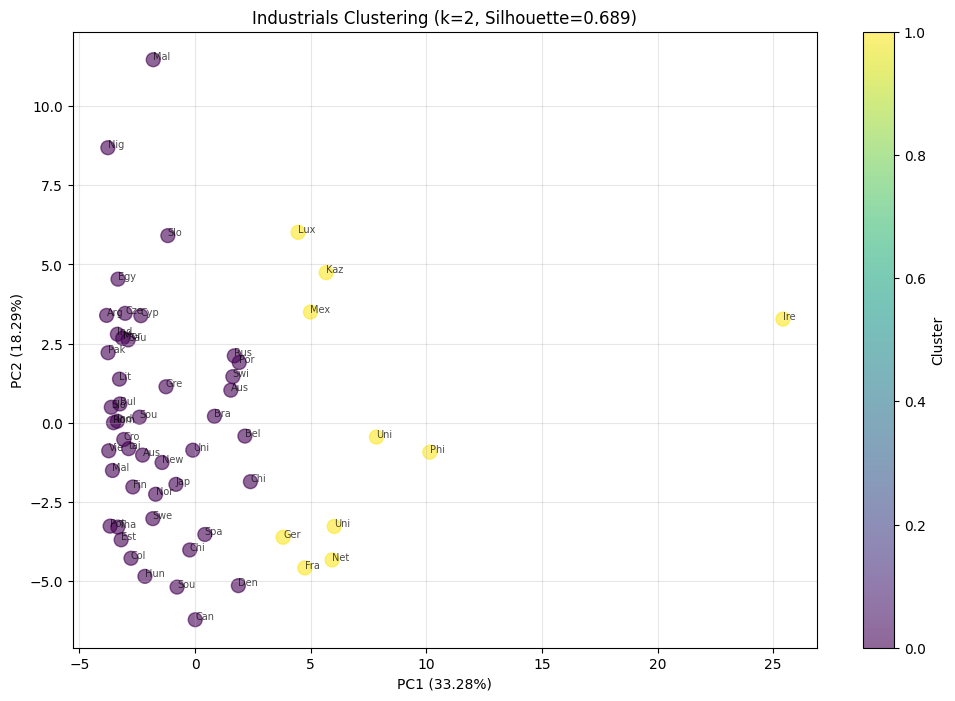


=== Industrials ===
Samples: 56
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.6885
Calinski-Harabasz Score: 75.3526
Davies-Bouldin Score: 0.5821
Cluster distribution:
  Cluster 0: 46 samples
  Cluster 1: 10 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'Greece', 'Hungary', 'India', 'Indonesia', 'Japan', 'Lithuania', 'Malaysia', 'Malta', 'Morocco', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'taiwan', 'Thailand', 'United Kingdom', 'Vietnam']
  Cluster 1: ['France', 'Germany', 'Ireland', 'Kazakhstan', 'Luxembourg', 'Mexico', 'Netherlands', 'Philippines', 'United Arab Emirates', 'United States']


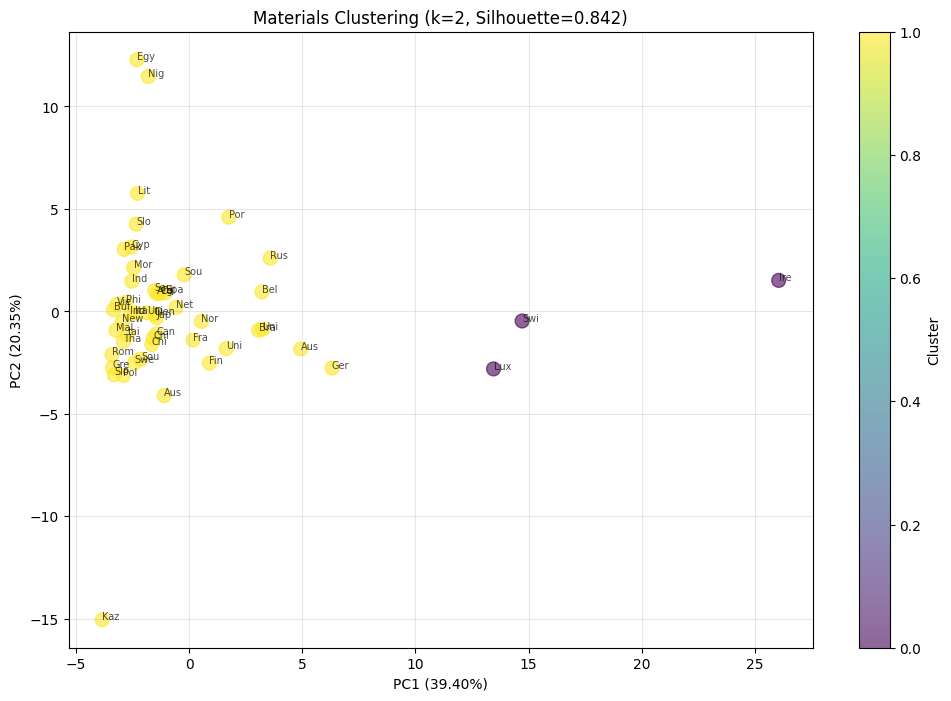


=== Materials ===
Samples: 51
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.8416
Calinski-Harabasz Score: 139.9898
Davies-Bouldin Score: 0.3710
Cluster distribution:
  Cluster 0: 3 samples
  Cluster 1: 48 samples
Countries by cluster:
  Cluster 0: ['Ireland', 'Luxembourg', 'Switzerland']
  Cluster 1: ['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Cyprus', 'Denmark', 'Egypt', 'Finland', 'France', 'Germany', 'Greece', 'India', 'Indonesia', 'Italy', 'Japan', 'Kazakhstan', 'Lithuania', 'Malaysia', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'taiwan', 'Thailand', 'United Arab Emirates', 'United Kingdom', 'United States', 'Vietnam']


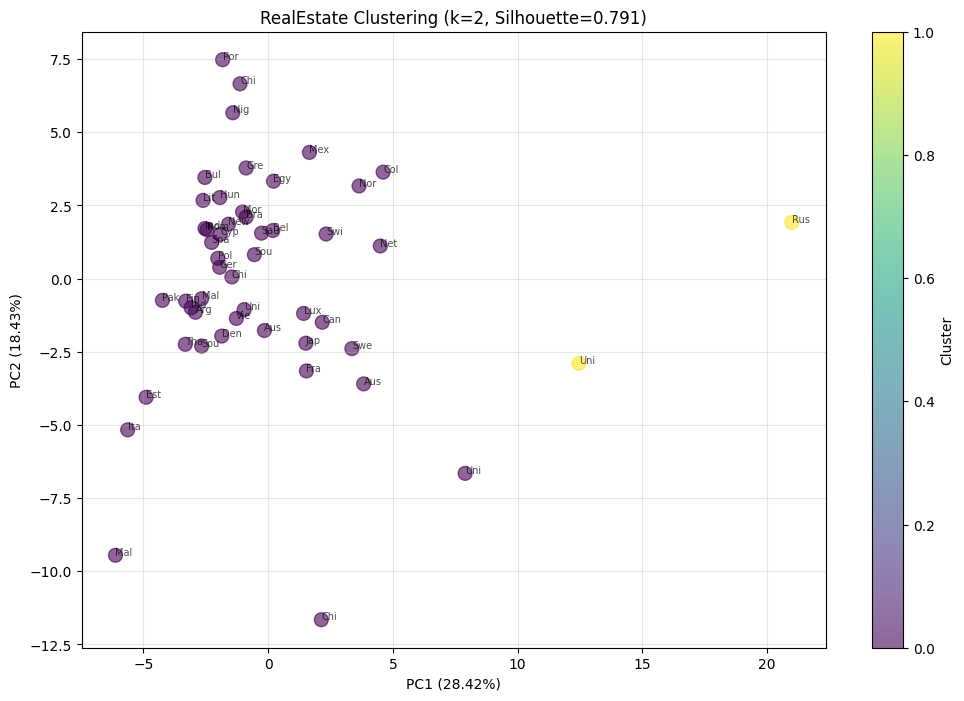


=== RealEstate ===
Samples: 50
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.7914
Calinski-Harabasz Score: 67.8685
Davies-Bouldin Score: 0.3707
Cluster distribution:
  Cluster 0: 48 samples
  Cluster 1: 2 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Chinese Taipei', 'Colombia', 'Cyprus', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Indonesia', 'Italy', 'Japan', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Poland', 'Portugal', 'Romania', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'United Kingdom', 'United States', 'Vietnam']
  Cluster 1: ['Russia', 'United Arab Emirates']


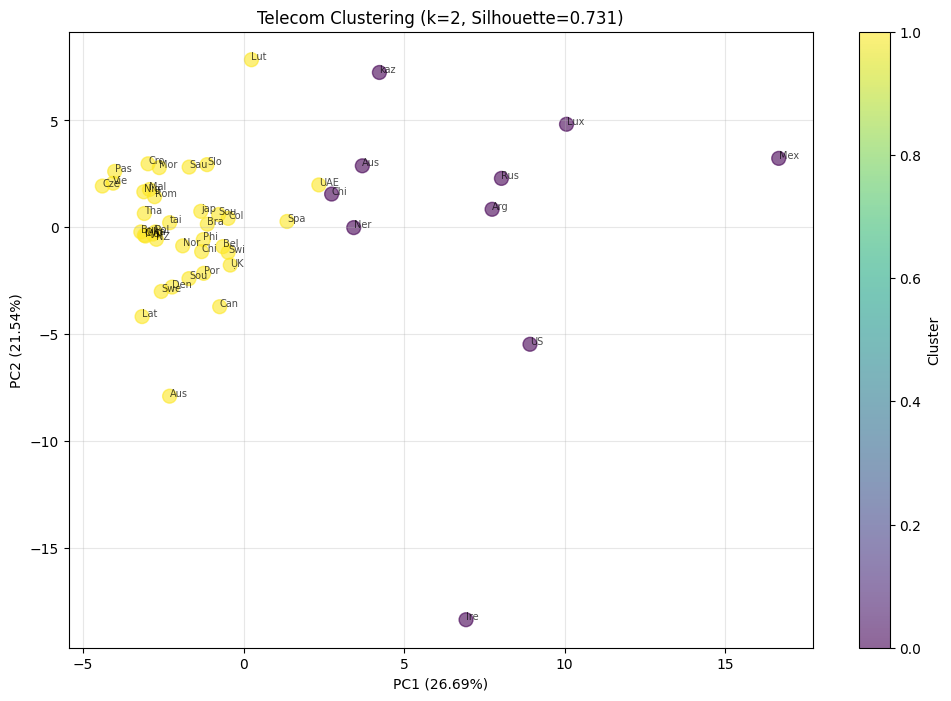


=== Telecom ===
Samples: 48
Optimal PCA components: 1
Optimal clusters: 2
Silhouette Score: 0.7308
Calinski-Harabasz Score: 130.1998
Davies-Bouldin Score: 0.4587
Cluster distribution:
  Cluster 0: 10 samples
  Cluster 1: 38 samples
Countries by cluster:
  Cluster 0: ['Argentina', 'Austria', 'Chile', 'Ireland', 'kazartan', 'Luxemb', 'Mexico', 'Nertheland', 'Russia', 'US']
  Cluster 1: ['Australia', 'Belgium', 'Brazil', 'Bulgatia', 'Canada', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Italy', 'japan', 'Latvia', 'Luthunia', 'Malay', 'Malta', 'Moroco', 'Nigieria', 'Norway', 'NZ', 'Paskistan', 'Phil', 'Poland', 'Portuga', 'Romania', 'Saudi', 'Slovenia', 'South Af', 'South Korea', 'Spain', 'Sweden', 'Swit', 'taiwan', 'Thailand', 'UAE', 'Vietnam', 'ỤK']


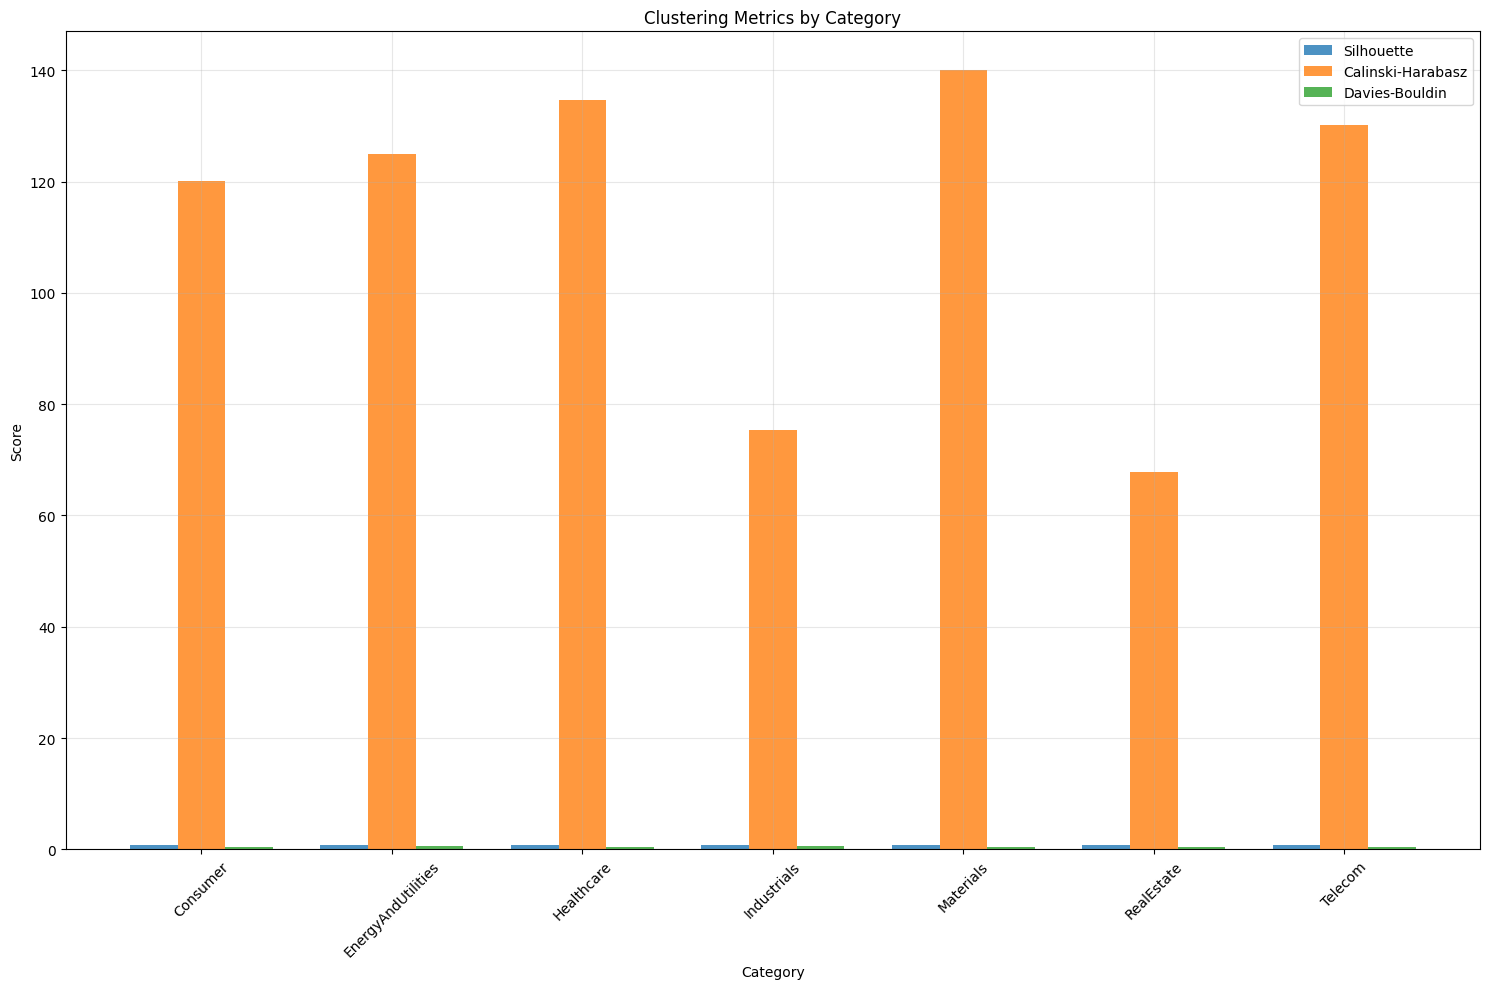


=== Summary Table ===
          Category  Samples  Optimal_Clusters  Silhouette  Calinski_Harabasz  Davies_Bouldin
          Consumer       58                 2    0.725804         120.169759        0.488163
EnergyAndUtilities       54                 2    0.781725         124.989805        0.536434
        Healthcare       50                 2    0.761441         134.697542        0.421255
       Industrials       56                 2    0.688504          75.352605        0.582113
         Materials       51                 2    0.841614         139.989769        0.371031
        RealEstate       50                 2    0.791395          67.868499        0.370661
           Telecom       48                 2    0.730773         130.199849        0.458735

Best clustering by Silhouette score: Materials
Summary saved to 'category_clustering_metrics.csv'


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

df = pd.read_csv('country_category_vectors.csv')
df_fy2024 = df[df['FiscalYear'] == 'FY2024']
df_fy2024 = df_fy2024.dropna()

categories = df_fy2024['Category'].unique()
all_metrics = []

for category in categories:
    df_category = df_fy2024[df_fy2024['Category'] == category]
    
    if len(df_category) < 2:
        continue
    
    X = df_category.iloc[:, 4:].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_components_range = range(1, min(10, X_scaled.shape[0], X_scaled.shape[1]))
    explained_variances = []
    
    for n in n_components_range:
        pca = PCA(n_components=n)
        X_pca = pca.fit_transform(X_scaled)
        explained_variances.append(np.sum(pca.explained_variance_ratio_))
    
    optimal_pca_idx = np.argmax(np.array(explained_variances) >= 0.95)
    optimal_pca_components = optimal_pca_idx + 1 if optimal_pca_idx < len(explained_variances) else len(explained_variances)
    
    pca_optimal = PCA(n_components=optimal_pca_components)
    X_pca_optimal = pca_optimal.fit_transform(X_scaled)
    
    silhouette_scores = []
    ch_scores = []
    db_scores = []
    k_range = range(2, min(10, len(df_category)))
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_pca_optimal)
        
        if len(np.unique(labels)) > 1:
            silhouette_scores.append(silhouette_score(X_pca_optimal, labels))
            ch_scores.append(calinski_harabasz_score(X_pca_optimal, labels))
            db_scores.append(davies_bouldin_score(X_pca_optimal, labels))
        else:
            silhouette_scores.append(0)
            ch_scores.append(0)
            db_scores.append(np.inf)
    
    optimal_k = k_range[np.argmax(silhouette_scores)] if silhouette_scores else 2
    
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    final_labels = kmeans_final.fit_predict(X_pca_optimal)
    
    silhouette_final = silhouette_score(X_pca_optimal, final_labels) if len(np.unique(final_labels)) > 1 else 0
    ch_final = calinski_harabasz_score(X_pca_optimal, final_labels) if len(np.unique(final_labels)) > 1 else 0
    db_final = davies_bouldin_score(X_pca_optimal, final_labels) if len(np.unique(final_labels)) > 1 else np.inf
    
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=final_labels, cmap='viridis', s=100, alpha=0.6)
    
    for idx, row in df_category.iterrows():
        plt.annotate(row['Country'][:3], (X_pca_2d[df_category.index.get_loc(idx), 0], 
                                         X_pca_2d[df_category.index.get_loc(idx), 1]),
                    fontsize=7, alpha=0.7)
    
    plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
    plt.title(f'{category} Clustering (k={optimal_k}, Silhouette={silhouette_final:.3f})')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'clustering_{category.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    unique, counts = np.unique(final_labels, return_counts=True)
    cluster_distribution = dict(zip(unique, counts))
    
    all_metrics.append({
        'Category': category,
        'Samples': len(df_category),
        'Optimal_PCA': optimal_pca_components,
        'Optimal_Clusters': optimal_k,
        'Silhouette': silhouette_final,
        'Calinski_Harabasz': ch_final,
        'Davies_Bouldin': db_final,
        'Cluster_Distribution': cluster_distribution
    })
    
    print(f"\n=== {category} ===")
    print(f"Samples: {len(df_category)}")
    print(f"Optimal PCA components: {optimal_pca_components}")
    print(f"Optimal clusters: {optimal_k}")
    print(f"Silhouette Score: {silhouette_final:.4f}")
    print(f"Calinski-Harabasz Score: {ch_final:.4f}")
    print(f"Davies-Bouldin Score: {db_final:.4f}")
    print("Cluster distribution:")
    for cluster, count in cluster_distribution.items():
        print(f"  Cluster {cluster}: {count} samples")
    
    countries_by_cluster = {}
    for cluster in np.unique(final_labels):
        cluster_indices = np.where(final_labels == cluster)[0]
        countries = df_category.iloc[cluster_indices]['Country'].tolist()
        countries_by_cluster[cluster] = countries
    
    print("Countries by cluster:")
    for cluster, countries in countries_by_cluster.items():
        print(f"  Cluster {cluster}: {countries}")

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv('category_clustering_metrics.csv', index=False)

plt.figure(figsize=(15, 10))
categories_list = [m['Category'] for m in all_metrics]
silhouette_vals = [m['Silhouette'] for m in all_metrics]
ch_vals = [m['Calinski_Harabasz'] for m in all_metrics]
db_vals = [m['Davies_Bouldin'] for m in all_metrics]

x = np.arange(len(categories_list))
width = 0.25

plt.bar(x - width, silhouette_vals, width, label='Silhouette', alpha=0.8)
plt.bar(x, ch_vals, width, label='Calinski-Harabasz', alpha=0.8)
plt.bar(x + width, db_vals, width, label='Davies-Bouldin', alpha=0.8)

plt.xlabel('Category')
plt.ylabel('Score')
plt.title('Clustering Metrics by Category')
plt.xticks(x, categories_list, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('category_metrics_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Summary Table ===")
print(metrics_df[['Category', 'Samples', 'Optimal_Clusters', 'Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin']].to_string(index=False))

best_category = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'Category']
print(f"\nBest clustering by Silhouette score: {best_category}")
print(f"Summary saved to 'category_clustering_metrics.csv'")

In [1]:
"""
Complete Clustering Analysis for FY2018-FY2025
Run this script to generate clustering results for all fiscal years
"""

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration
base_dir = Path('E:/hneu/processed_data')
output_dir = Path('./clustering_results')
output_dir.mkdir(exist_ok=True)

# Fiscal years to analyze
fiscal_years = ['FY2018', 'FY2019', 'FY2020', 'FY2021', 
                'FY2022', 'FY2023', 'FY2024', 'FY2025']

indicator_base_names = [
    'Gross Profit Margin\n(%)',
    'EBITDA Margin\n(%)',
    'Net Income Margin\n(%)',
    'Return on Assets\n(%)',
    'Return on Capital\n(%)',
    'Return on Equity\n(%)',
    'Total Revenues, 1 Year Growth\n(%)',
    'Gross Profit\n($000)',
    'Interest Expense\n($000)',
    'Net Property, Plant & Equipment\n($000)',
    'Total Assets\n($000)',
    'Total Debt\n($000)',
    'Total Equity\n($000)',
    'Capital Expenditure\n($000)'
]

def load_and_prepare_data():
    """Load and prepare data from parquet files"""
    all_data = []
    
    for category_dir in base_dir.iterdir():
        if not category_dir.is_dir():
            continue
        
        category_name = category_dir.name
        
        for country_dir in category_dir.iterdir():
            if not country_dir.is_dir():
                continue
            
            country_name = country_dir.name
            
            for parquet_file in country_dir.glob('*.parquet'):
                df = pd.read_parquet(parquet_file)
                
                for fy in fiscal_years + ['Latest Fiscal Year']:
                    fy_label = 'FY2025' if fy == 'Latest Fiscal Year' else fy
                    
                    indicator_cols = [f'{ind}_{fy}' for ind in indicator_base_names]
                    available_cols = [col for col in indicator_cols if col in df.columns]
                    
                    if len(available_cols) < len(indicator_base_names):
                        continue
                    
                    df_fy = df[available_cols].copy()
                    df_fy = df_fy.dropna()
                    
                    if len(df_fy) == 0:
                        continue
                    
                    aggregated_values = []
                    
                    for col in available_cols:
                        values = df_fy[col].values
                        
                        if len(values) > 0:
                            aggregated_values.extend([
                                np.mean(values),
                                np.std(values),
                                np.median(values),
                                np.percentile(values, 25),
                                np.percentile(values, 75)
                            ])
                        else:
                            aggregated_values.extend([np.nan] * 5)
                    
                    all_data.append({
                        'Category': category_name,
                        'Country': country_name,
                        'FiscalYear': fy_label,
                        'Vector': aggregated_values,
                        'NumCompanies': len(df_fy)
                    })
    
    df_aggregated = pd.DataFrame(all_data)
    vector_df = pd.DataFrame(df_aggregated['Vector'].tolist())
    df_final = pd.concat([df_aggregated[['Category', 'Country', 'FiscalYear', 'NumCompanies']], 
                         vector_df], axis=1)
    
    return df_final.dropna()

def perform_country_category_clustering(df_year, year):
    """Approach 1: Cluster country-category pairs together"""
    if len(df_year) < 2:
        print(f"Not enough data for {year} country-category clustering")
        return None
    
    X = df_year.iloc[:, 4:].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_components = min(10, X_scaled.shape[1], X_scaled.shape[0])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    silhouette_scores = []
    k_range = range(2, min(8, len(df_year) - 1))
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_pca)
        if len(np.unique(labels)) > 1:
            silhouette_scores.append(silhouette_score(X_pca, labels))
        else:
            silhouette_scores.append(0)
    
    optimal_k = k_range[np.argmax(silhouette_scores)] if silhouette_scores else min(3, len(df_year))
    
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_year['Cluster'] = kmeans.fit_predict(X_pca)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    tsne = TSNE(n_components=2, random_state=42, 
                perplexity=min(30, len(df_year) - 1))
    X_tsne = tsne.fit_transform(X_pca)
    
    scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=df_year['Cluster'], 
                              cmap='tab20', 
                              s=100, 
                              alpha=0.6)
    
    for idx, row in df_year.iterrows():
        axes[0].annotate(f"{row['Country'][:3]}-{row['Category'][:3]}", 
                        (X_tsne[df_year.index.get_loc(idx), 0], 
                         X_tsne[df_year.index.get_loc(idx), 1]),
                        fontsize=7, alpha=0.7)
    
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    axes[0].set_title(f'{year}: Country-Category Clusters (t-SNE)')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    
    scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                              c=df_year['Cluster'], 
                              cmap='tab20', 
                              s=100, 
                              alpha=0.6)
    
    for idx, row in df_year.iterrows():
        axes[1].annotate(f"{row['Country'][:3]}-{row['Category'][:3]}", 
                        (X_pca_2d[df_year.index.get_loc(idx), 0], 
                         X_pca_2d[df_year.index.get_loc(idx), 1]),
                        fontsize=7, alpha=0.7)
    
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
    axes[1].set_title(f'{year}: Country-Category Clusters (PCA)')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Cluster')
    
    plt.tight_layout()
    plt.savefig(output_dir / f'{year}_country_category_clusters.png', 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    return df_year, optimal_k, silhouette_scores[np.argmax(silhouette_scores)]

def perform_category_fixed_clustering(df_year, year):
    """Approach 2: Cluster countries within each fixed category"""
    categories = df_year['Category'].unique()
    all_results = []
    
    for category in categories:
        df_category = df_year[df_year['Category'] == category].copy()
        
        if len(df_category) < 3:
            continue
        
        X = df_category.iloc[:, 4:-1].values
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_components_range = range(1, min(6, X_scaled.shape[0], X_scaled.shape[1]))
        explained_variances = []
        
        for n in n_components_range:
            pca = PCA(n_components=n)
            X_pca = pca.fit_transform(X_scaled)
            explained_variances.append(np.sum(pca.explained_variance_ratio_))
        
        optimal_pca_idx = np.argmax(np.array(explained_variances) >= 0.90)
        optimal_pca_components = optimal_pca_idx + 1 if optimal_pca_idx < len(explained_variances) else len(explained_variances)
        
        pca_optimal = PCA(n_components=optimal_pca_components)
        X_pca_optimal = pca_optimal.fit_transform(X_scaled)
        
        silhouette_scores = []
        k_range = range(2, min(6, len(df_category)))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_pca_optimal)
            
            if len(np.unique(labels)) > 1:
                silhouette_scores.append(silhouette_score(X_pca_optimal, labels))
            else:
                silhouette_scores.append(0)
        
        optimal_k = k_range[np.argmax(silhouette_scores)] if silhouette_scores else 2
        
        kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        df_category['Cluster'] = kmeans_final.fit_predict(X_pca_optimal)
        
        silhouette_final = silhouette_score(X_pca_optimal, df_category['Cluster']) if len(np.unique(df_category['Cluster'])) > 1 else 0
        ch_final = calinski_harabasz_score(X_pca_optimal, df_category['Cluster']) if len(np.unique(df_category['Cluster'])) > 1 else 0
        db_final = davies_bouldin_score(X_pca_optimal, df_category['Cluster']) if len(np.unique(df_category['Cluster'])) > 1 else np.inf
        
        pca_2d = PCA(n_components=2)
        X_pca_2d = pca_2d.fit_transform(X_scaled)
        
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=df_category['Cluster'], 
                             cmap='viridis', 
                             s=100, 
                             alpha=0.6)
        
        for idx, row in df_category.iterrows():
            plt.annotate(row['Country'][:3], 
                        (X_pca_2d[df_category.index.get_loc(idx), 0], 
                         X_pca_2d[df_category.index.get_loc(idx), 1]),
                        fontsize=8, alpha=0.7)
        
        plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
        plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
        plt.title(f'{year} - {category}: Country Clusters\nk={optimal_k}, Silhouette={silhouette_final:.3f}')
        plt.colorbar(scatter, label='Cluster')
        plt.grid(True, alpha=0.3)
        
        category_safe = category.replace(' ', '_').replace('/', '_')
        plt.savefig(output_dir / f'{year}_{category_safe}_country_clusters.png', 
                    dpi=300, bbox_inches='tight')
        plt.close()
        
        cluster_distribution = df_category['Cluster'].value_counts().to_dict()
        countries_by_cluster = df_category.groupby('Cluster')['Country'].apply(list).to_dict()
        
        all_results.append({
            'Year': year,
            'Category': category,
            'Samples': len(df_category),
            'Optimal_Clusters': optimal_k,
            'Silhouette': silhouette_final,
            'Calinski_Harabasz': ch_final,
            'Davies_Bouldin': db_final,
            'Cluster_Distribution': cluster_distribution,
            'Countries_by_Cluster': countries_by_cluster,
            'All_Countries': df_category['Country'].tolist()
        })
        
        df_year.loc[df_category.index, 'Category_Cluster'] = df_category['Cluster']
    
    return pd.DataFrame(all_results)

def generate_output_file(results_df, year, country_category_results):
    """Generate output.txt file with clustering results"""
    output_file = output_dir / f'{year}_output.txt'
    
    with open(output_file, 'w') as f:
        f.write(f"=== CLUSTERING ANALYSIS RESULTS FOR {year} ===\n\n")
        
        f.write("1. COUNTRY-CATEGORY SIMULTANEOUS CLUSTERING\n")
        f.write("=" * 50 + "\n")
        f.write(f"Total pairs: {len(country_category_results[0])}\n")
        f.write(f"Optimal clusters: {country_category_results[1]}\n")
        f.write(f"Silhouette score: {country_category_results[2]:.4f}\n\n")
        
        f.write("Cluster Assignments:\n")
        f.write("-" * 30 + "\n")
        
        for cluster_num in sorted(country_category_results[0]['Cluster'].unique()):
            cluster_data = country_category_results[0][country_category_results[0]['Cluster'] == cluster_num]
            f.write(f"\nCluster {cluster_num} ({len(cluster_data)} pairs):\n")
            
            for _, row in cluster_data.iterrows():
                f.write(f"  {row['Country']} - {row['Category']} "
                       f"(Companies: {row['NumCompanies']})\n")
        
        f.write("\n\n2. COUNTRY CLUSTERING WITHIN FIXED CATEGORIES\n")
        f.write("=" * 50 + "\n")
        
        if not results_df.empty:
            for _, row in results_df.iterrows():
                f.write(f"\nCategory: {row['Category']}\n")
                f.write(f"Samples: {row['Samples']}\n")
                f.write(f"Optimal clusters: {row['Optimal_Clusters']}\n")
                f.write(f"Silhouette: {row['Silhouette']:.4f}\n")
                f.write(f"Calinski-Harabasz: {row['Calinski_Harabasz']:.2f}\n")
                f.write(f"Davies-Bouldin: {row['Davies_Bouldin']:.2f}\n")
                
                f.write("Cluster Distribution:\n")
                for cluster, count in row['Cluster_Distribution'].items():
                    countries = row['Countries_by_Cluster'].get(cluster, [])
                    f.write(f"  Cluster {cluster}: {count} countries - {countries}\n")
        
        f.write("\n\n3. SUMMARY STATISTICS\n")
        f.write("=" * 50 + "\n")
        f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Fiscal Years Analyzed: 1 ({year})\n")
        
        if not results_df.empty:
            f.write(f"Categories with clustering: {len(results_df)}\n")
            best_category = results_df.loc[results_df['Silhouette'].idxmax(), 'Category']
            f.write(f"Best clustering by Silhouette: {best_category}\n")
    
    print(f"Output saved to {output_file}")

def main():
    """Main execution function"""
    print("Loading and preparing data...")
    df_final = load_and_prepare_data()
    
    if df_final.empty:
        print("No data available. Check your data directory and files.")
        return
    
    print(f"Total data points loaded: {len(df_final)}")
    
    for year in fiscal_years:
        print(f"\n{'='*60}")
        print(f"Analyzing {year}")
        print('='*60)
        
        df_year = df_final[df_final['FiscalYear'] == year].copy()
        
        if len(df_year) == 0:
            print(f"No data available for {year}")
            continue
        
        print(f"Data points for {year}: {len(df_year)}")
        print(f"Categories: {df_year['Category'].nunique()}")
        print(f"Countries: {df_year['Country'].nunique()}")
        
        print("\nPerforming Country-Category Clustering...")
        country_category_results = perform_country_category_clustering(df_year.copy(), year)
        
        if country_category_results:
            print("Performing Category-Fixed Clustering...")
            category_results_df = perform_category_fixed_clustering(df_year.copy(), year)
            
            generate_output_file(category_results_df, year, country_category_results)
            
            df_year.to_csv(output_dir / f'{year}_detailed_results.csv', index=False)
            
            if not category_results_df.empty:
                category_results_df.to_csv(output_dir / f'{year}_category_metrics.csv', index=False)
                
                plt.figure(figsize=(12, 6))
                categories = category_results_df['Category']
                silhouette_vals = category_results_df['Silhouette']
                
                plt.bar(categories, silhouette_vals, color='steelblue', alpha=0.7)
                plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Good threshold (0.5)')
                plt.axhline(y=0.25, color='y', linestyle='--', alpha=0.5, label='Fair threshold (0.25)')
                
                plt.xlabel('Category')
                plt.ylabel('Silhouette Score')
                plt.title(f'{year}: Clustering Quality by Category')
                plt.xticks(rotation=45)
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(output_dir / f'{year}_clustering_quality_summary.png', 
                           dpi=300, bbox_inches='tight')
                plt.close()
        
        print(f"Analysis for {year} completed successfully!")
    
    print(f"\n{'='*60}")
    print("ANALYSIS COMPLETE")
    print('='*60)
    print(f"All results saved to: {output_dir.absolute()}")
    print("\nGenerated files for each fiscal year:")
    print("1. Country-category cluster visualization (PNG)")
    print("2. Category-specific country cluster visualizations (PNG)")
    print("3. Detailed output with cluster assignments (TXT)")
    print("4. Detailed results CSV files")
    print("5. Clustering quality summary (PNG)")

if __name__ == "__main__":
    main()

Loading and preparing data...
Total data points loaded: 2840

Analyzing FY2018
Data points for FY2018: 311
Categories: 7
Countries: 59

Performing Country-Category Clustering...
Performing Category-Fixed Clustering...
Output saved to clustering_results\FY2018_output.txt
Analysis for FY2018 completed successfully!

Analyzing FY2019
Data points for FY2019: 363
Categories: 7
Countries: 78

Performing Country-Category Clustering...
Performing Category-Fixed Clustering...


UnicodeEncodeError: 'charmap' codec can't encode character '\u1ee4' in position 2: character maps to <undefined>